In [65]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
# Load dataset

df = pd.read_csv("student.csv")

# Display first 5 rows

df.head()

,student_id,first_name,last_name,age,email,country,grade_math,grade_science,grade_english,total_score
0,1,Kerrill,De Cleyne,24,kdecleyne0@furl.net,Venezuela,68,80,15,54
1,2,Krissie,Vittet,25,kvittet1@ustream.tv,Bulgaria,29,30,60,39
2,3,Hugibert,Haugg,21,hhaugg2@theguardian.com,New Zealand,76,0,55,43
3,4,Fancie,De Mars,18,fdemars3@parallels.com,China,82,88,90,86
4,5,Micki,O'Dowgaine,24,modowgaine4@livejournal.com,China,77,23,11,37


In [68]:
# Shape of dataset

print("Dataset Shape:", df.shape)

# Column names

print("\nColumns:")
print(df.columns)

# Information about dataset

print("\nDataset Info:")
df.info()

Dataset Shape: (1000, 10)

Columns:
Index(['student_id', 'first_name', 'last_name', 'age', 'email', 'country',
       'grade_math', 'grade_science', 'grade_english', 'total_score'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     1000 non-null   int64 
 1   first_name     1000 non-null   object
 2   last_name      1000 non-null   object
 3   age            1000 non-null   int64 
 4   email          1000 non-null   object
 5   country        1000 non-null   object
 6   grade_math     1000 non-null   int64 
 7   grade_science  1000 non-null   int64 
 8   grade_english  1000 non-null   int64 
 9   total_score    1000 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 78.3+ KB


In [69]:
# Check missing values

print(df.isnull().sum())

student_id       0
first_name       0
last_name        0
age              0
email            0
country          0
grade_math       0
grade_science    0
grade_english    0
total_score      0
dtype: int64


In [70]:
# Save a backup copy

df.to_csv("student_backup.csv", index=False)

print("Backup file created successfully.")

Backup file created successfully.


In [72]:
sorted_df = df.sort_values(by="total_score", ascending=False)

sorted_df.head()

,student_id,first_name,last_name,age,email,country,grade_math,grade_science,grade_english,total_score
182,183,Terence,Rooson,20,trooson52@businessinsider.com,Vietnam,86,91,99,92
27,28,Lloyd,Yeliashev,18,lyeliashevr@hud.gov,China,87,94,92,91
231,232,Gaylord,Crumley,25,gcrumley6f@upenn.edu,Peru,99,88,84,90
736,737,Abe,Bartolomeu,21,abartolomeukg@microsoft.com,Indonesia,78,97,96,90
17,18,Ninetta,Carrane,20,ncarraneh@etsy.com,Slovenia,78,98,95,90


In [73]:
country_groups = df.groupby("country")

print(country_groups.size())

country
Afghanistan     5
Albania         4
Argentina      20
Armenia         3
Australia       1
               ..
Venezuela       5
Vietnam        11
Yemen           1
Zambia          1
Zimbabwe        1
Length: 118, dtype: int64


In [74]:
# Integrating first and last names

df["full_name"] = df["first_name"] + " " + df["last_name"]

df[["first_name", "last_name", "full_name"]].head()

,first_name,last_name,full_name
0,Kerrill,De Cleyne,Kerrill De Cleyne
1,Krissie,Vittet,Krissie Vittet
2,Hugibert,Haugg,Hugibert Haugg
3,Fancie,De Mars,Fancie De Mars
4,Micki,O'Dowgaine,Micki O'Dowgaine


In [75]:
df["country"] = df["country"].str.upper()

df["country"].head()

0      VENEZUELA
1       BULGARIA
2    NEW ZEALAND
3          CHINA
4          CHINA
Name: country, dtype: object

In [76]:
# Check duplicates

print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

Duplicate Rows: 0


In [77]:
# Check data types

print(df.dtypes)

student_id        int64
first_name       object
last_name        object
age               int64
email            object
country          object
grade_math        int64
grade_science     int64
grade_english     int64
total_score       int64
full_name        object
dtype: object


In [79]:
# Fill missing numerical values with mean

numeric_columns = ["grade_math", "grade_science", "grade_english", "total_score"]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

In [80]:
df.describe()

,student_id,age,grade_math,grade_science,grade_english,total_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,21.536000,50.057000,48.335000,50.634000,49.341000
std,288.819436,2.275936,28.868723,29.229114,29.896619,16.801399
min,1.000000,18.000000,0.000000,0.000000,0.000000,7.000000
25%,250.750000,20.000000,24.000000,24.000000,24.000000,37.000000
50%,500.500000,21.000000,51.000000,47.000000,50.000000,49.500000
75%,750.250000,23.000000,74.000000,74.000000,77.250000,62.000000
max,1000.000000,25.000000,100.000000,100.000000,100.000000,92.000000


In [81]:
selected_data = df[[
    "grade_math",
    "grade_science",
    "grade_english",
    "total_score"
]]

selected_data.head()

,grade_math,grade_science,grade_english,total_score
0,68,80,15,54
1,29,30,60,39
2,76,0,55,43
3,82,88,90,86
4,77,23,11,37


In [82]:
# Correlation matrix

correlation = selected_data.corr()

print(correlation)

               grade_math  grade_science  grade_english  total_score
grade_math       1.000000      -0.010704      -0.025108     0.551709
grade_science   -0.010704       1.000000       0.012542     0.580830
grade_english   -0.025108       0.012542       1.000000     0.585610
total_score      0.551709       0.580830       0.585610     1.000000


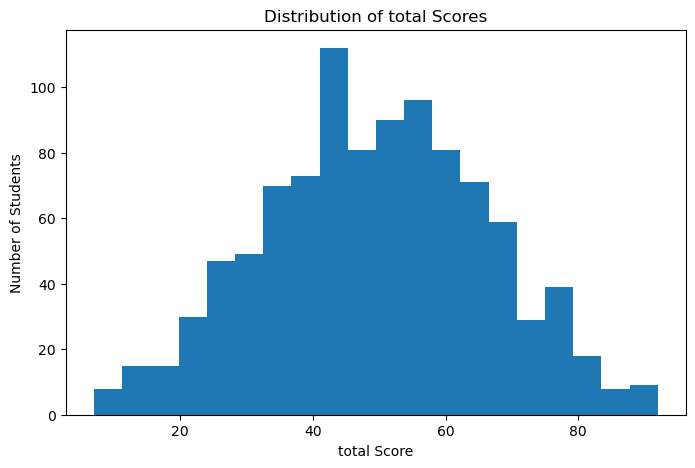

In [83]:
plt.figure(figsize=(8,5))

plt.hist(df["total_score"], bins=20)

plt.title("Distribution of total Scores")
plt.xlabel("total Score")
plt.ylabel("Number of Students")

plt.show()

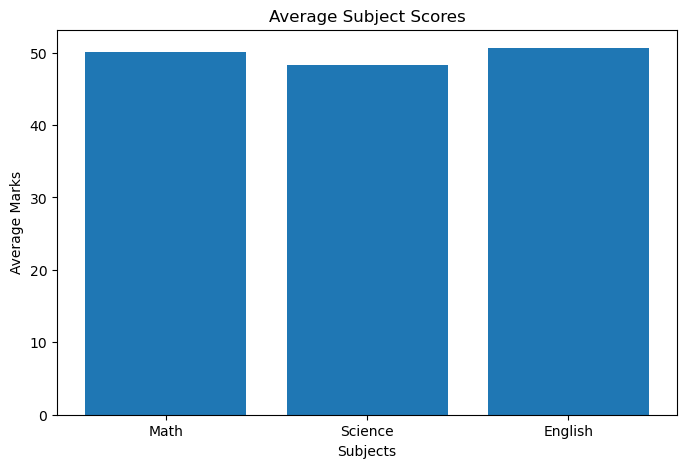

In [84]:
subject_means = [
    df["grade_math"].mean(),
    df["grade_science"].mean(),
    df["grade_english"].mean()
]

subjects = ["Math", "Science", "English"]

plt.figure(figsize=(8,5))

plt.bar(subjects, subject_means)

plt.title("Average Subject Scores")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.show()

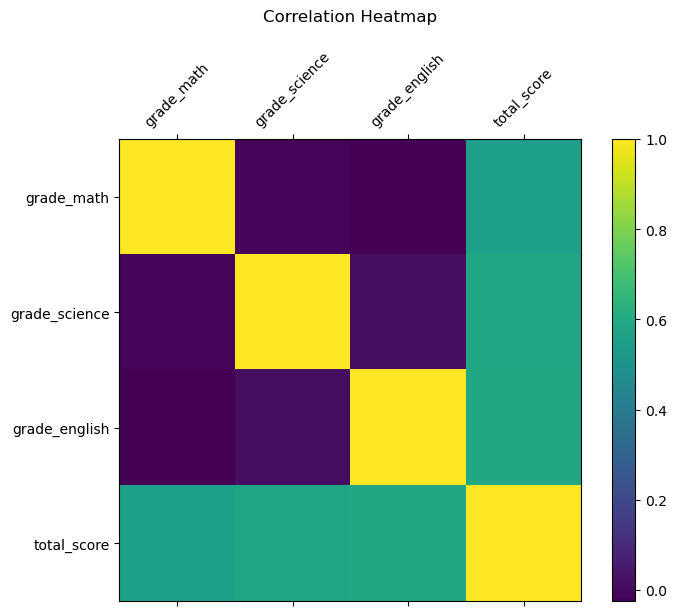

In [85]:
import matplotlib.pyplot as plt

corr = selected_data.corr()

fig, ax = plt.subplots(figsize=(8,6))

cax = ax.matshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

fig.colorbar(cax)

plt.title("Correlation Heatmap", pad=20)

plt.show()

In [87]:
def performance(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Average"

    else:
        return "Poor"

df["Performance"] = df["total_score"].apply(performance)

df[["total_score", "Performance"]].head()

,total_score,Performance
0,54,Average
1,39,Poor
2,43,Average
3,86,Excellent
4,37,Poor


In [88]:
performance_count = df["Performance"].value_counts()

print(performance_count)

Performance
Average      433
Poor         290
Good         242
Excellent     35
Name: count, dtype: int64


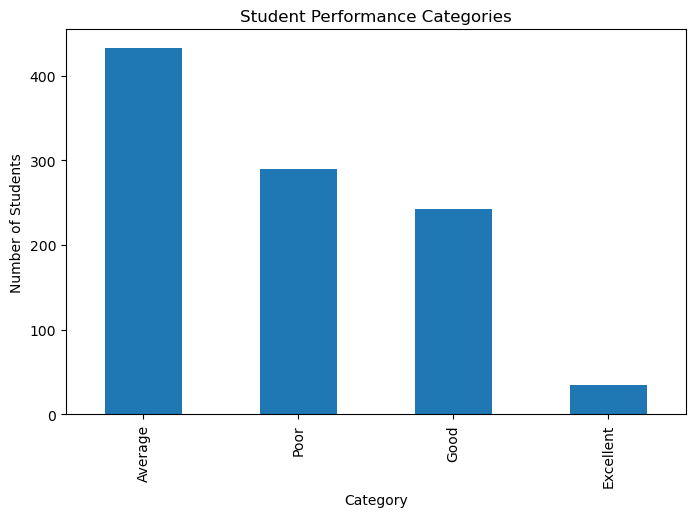

In [89]:
plt.figure(figsize=(8,5))

performance_count.plot(kind='bar')

plt.title("Student Performance Categories")
plt.xlabel("Category")
plt.ylabel("Number of Students")

plt.show()

In [90]:
country_performance = df.groupby("country")["total_score"].mean().sort_values(ascending=False)

print(country_performance.head(10))

country
LIBYA                               72.000000
MARTINIQUE                          71.000000
BOLIVIA                             69.000000
AUSTRIA                             67.000000
MONGOLIA                            66.000000
MALAYSIA                            63.666667
MICRONESIA                          63.000000
DOMINICAN REPUBLIC                  61.666667
DEMOCRATIC REPUBLIC OF THE CONGO    61.000000
COMOROS                             61.000000
Name: total_score, dtype: float64


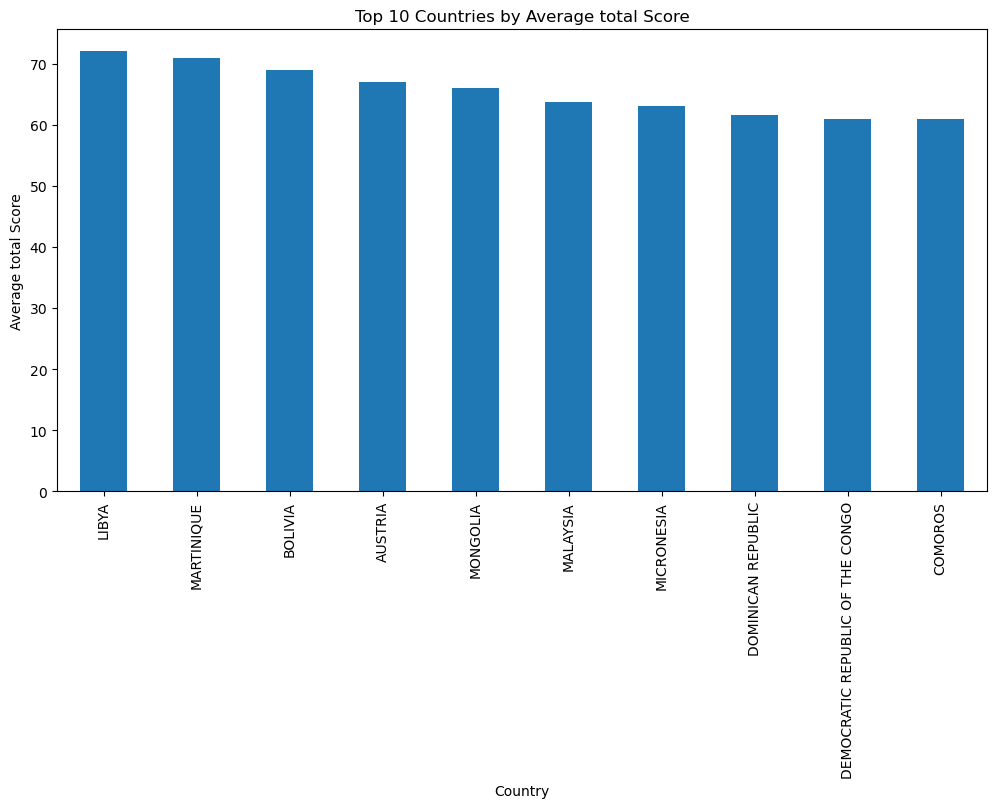

In [91]:
top_countries = country_performance.head(10)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Average total Score")
plt.xlabel("Country")
plt.ylabel("Average total Score")

plt.show()

In [92]:
df.to_csv("processed_student_data.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


Conclusion:

In this practical, large dataset concepts including Data Storage,
Data Integration, and Pattern Discovery were implemented using Python.

The student dataset was loaded, cleaned, organized, and validated.
Different analytical techniques such as correlation analysis,
classification, grouping, and visualization were performed.

Patterns such as student performance distribution,
subject-wise averages, and country-wise performance trends
were successfully identified using Data Analytics techniques.